## Steps To DO (4/16/2026)
1. Analyze Log Price, ensure all models use the same metric for scoring
2. Check for data leakage within the models
3. Ensure all required models are included

## Intercept Only Model

In [1]:
import pandas as pd 

# importing master dataset
df = pd.read_csv("master_zillow_with_taxes.csv")

# checking dataset 
display(df.head(2))

,Unnamed: 0,zpid,address,price,beds,baths,area_sqft,latitude,longitude,status,...,state_code,zipcode,state_name,state_avg_housing_value,state_avg_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets
0,0,17264897,"979 Kevin Ave, Redlands, CA 92373",447000,3,2.0,1300.0,34.040520,-117.186195,House for sale,...,CA,92373,California,604112.069,0.688448,4024.142857,9.3,72724.0,9.3,145448.0
1,1,20021372,"13114 Addison St, Sherman Oaks, CA 91423",2795000,4,5.0,2900.0,34.160885,-118.418770,House for sale,...,CA,91423,California,604112.069,0.688448,4024.142857,9.3,72724.0,9.3,145448.0


In [2]:
from sklearn.linear_model import LinearRegression
import numpy as np

# setting response variable
y = df['price']

# setting an array of ones to same number of rows in the master dataset 
X = np.ones((len(df), 1))

# fitting the model with the intercept only
model = LinearRegression().fit(X, y)
print(f"Intercept: {model.intercept_}")

# validating 
intercept = df['price'].mean()
print(f"Correct Intercept: {intercept}")

Intercept: 1350735.0768874479
Correct Intercept: 1350735.0768874479


## Lasso & Ridge Regularization Models
**Code in Github also removes new and variatnts of coming soon, potentially include them?**

In [15]:
# Imports
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [4]:
# Filtering the dataframe to only have houses that can  be purchased
print('======Before======')
print(df['status'].value_counts())

drop_vals = ['Coming Soon', 'Coming soon','Foreclosure', 'Auction', 'New']
df_filtered = df[~df['status'].isin(drop_vals)]
print('======After======')
print(df_filtered['status'].value_counts())
# Checking how many null values 
df_filtered.isnull().sum()
# Using the median for null values in area_sqft
df_filtered["area_sqft"] = df_filtered["area_sqft"].fillna(
    df_filtered["area_sqft"].median()
)
# Only had 1 null in longitude and latitude so decided to drop it
df_filtered = df_filtered.dropna(subset=["latitude", "longitude"])
df_filtered.isnull().sum()

======Before======
status
House for sale           1494
Active                    353
Coming soon               223
Condo for sale             19
Active Under Contract      14
Townhouse for sale         14
New construction           13
Foreclosure                11
For sale by owner           8
Auction                     6
Coming Soon                 3
New                         1
Name: count, dtype: int64
======After======
status
House for sale           1494
Active                    353
Condo for sale             19
Active Under Contract      14
Townhouse for sale         14
New construction           13
For sale by owner           8
Name: count, dtype: int64


C:\Users\brend\AppData\Local\Temp\ipykernel_35984\3010362903.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["area_sqft"] = df_filtered["area_sqft"].fillna(


Unnamed: 0                           0
zpid                                 0
address                              0
price                                0
beds                                 0
baths                                0
area_sqft                            0
latitude                             0
longitude                            0
status                               0
home_type                            0
days_on_zillow                       0
zestimate                          926
detail_url                           0
has_open_house                       0
is_featured                          0
street_add                           0
city                                 0
state_zipcode                        0
state_code                           0
zipcode                              0
state_name                           0
state_avg_housing_value              0
state_avg_prop_tax_rate              0
med_prop_tax_paid                    0
single_filer_rates       

In [5]:
#Trying to get rid of extreme outliers on both the low and high ends of prices
df_filtered = df_filtered[df_filtered['price'] > 10000]

cap = df_filtered['price'].quantile(0.99)
print(f"Capping at: ${cap:,.0f}")
df_filtered = df_filtered[df_filtered['price'] <= cap]

print(f"Rows remaining: {len(df_filtered)}")
print(df_filtered['price'].describe())

Capping at: $22,983,600
Rows remaining: 1893
count    1.893000e+03
mean     7.900074e+05
std      1.571539e+06
min      1.790000e+04
25%      3.390000e+05
50%      4.990000e+05
75%      7.620000e+05
max      2.290000e+07
Name: price, dtype: float64


In [6]:
# Dropping columns that are redundant or unhelpful
# Not sure if I should include zestimate, is_featured, and has_opened_house
# Also not sure about zipcode, city, and state name because they are string and if you one hot encode it would be a lot of columns
features = ['beds', 'baths', 'area_sqft', 'latitude', 'longitude', 'home_type', 
            'days_on_zillow', 'state_avg_housing_value', 'state_avg_prop_tax_rate', 
            'med_prop_tax_paid']
target = 'price'

X = df_filtered[features]
# Adding dummy variables for one-hot encoding
X = pd.get_dummies(X, columns=["home_type"], drop_first=True)
# Changing the target outcome to be between 0 and 1
y = np.log(df_filtered[target])

# Splitting the data with 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Just checking if the train and test data will look similar as I have been cleaning and dropping alot
train_df = X_train.copy()
test_df = X_test.copy()

train_df["price"] = y_train
test_df["price"] = y_test

print("TRAIN SUMMARY")
print(train_df.describe())

print("\nTEST SUMMARY")
print(test_df.describe())

TRAIN SUMMARY
              beds        baths     area_sqft     latitude    longitude  \
count  1514.000000  1514.000000   1514.000000  1514.000000  1514.000000   
mean      3.652576     2.831572   2539.266182    39.336758   -93.330114   
std       1.099557     1.248410   1772.320456     4.681565    16.623753   
min       0.000000     0.000000      0.000000    27.480639  -124.097000   
25%       3.000000     2.000000   1666.250000    35.918706  -108.525145   
50%       4.000000     3.000000   2214.000000    39.606266   -90.604162   
75%       4.000000     3.000000   2846.250000    42.769367   -78.558770   
max      17.000000    12.000000  29087.000000    48.790657   -69.429490   

       days_on_zillow  state_avg_housing_value  state_avg_prop_tax_rate  \
count     1514.000000              1514.000000              1514.000000   
mean        24.057464            293956.705485                 0.909336   
std         61.957867            127860.474811                 0.491118   
min       

In [8]:
# Scaling the data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

alphas = np.logspace(-3, 6, 200)
alphas

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_sc, y_train)

print("Best alpha (Ridge):", ridge.alpha_)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train_sc, y_train)

print("Best alpha (Lasso):", lasso.alpha_)


for name, model in [('Lasso', lasso), ('Ridge', ridge)]:
    y_pred_test = model.predict(X_test_sc)
    y_pred_train = model.predict(X_train_sc)
    mse_test  = mean_squared_error(y_test, y_pred_test)
    mse_train  = mean_squared_error(y_train, y_pred_train)
    rmse_test = np.sqrt(mse_test)
    rmse_train = np.sqrt(mse_train)
    r2_test   = r2_score(y_test, y_pred_test)
    r2_train   = r2_score(y_train, y_pred_train)
    print(f"\n{name}")
    print(f"  Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f}")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train R2:  {r2_train:.4f} | Test R2:  {r2_test:.4f}")

# Finding out which coefficients had the bigger impact
feature_names = X.columns
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

lasso_sorted = lasso_coefs.reindex(
    lasso_coefs.abs().sort_values(ascending=False).index
)
ridge_coefs = pd.Series(ridge.coef_, index=feature_names)

ridge_sorted = ridge_coefs.reindex(
    ridge_coefs.abs().sort_values(ascending=False).index
)

Best alpha (Ridge): 217.11179456945052
Best alpha (Lasso): 0.01663816886076129

Lasso
  Train MSE: 0.2472 | Test MSE: 0.2223
  Train RMSE: 0.4972 | Test RMSE: 0.4715
  Train R2:  0.5577 | Test R2:  0.6061

Ridge
  Train MSE: 0.2480 | Test MSE: 0.2234
  Train RMSE: 0.4980 | Test RMSE: 0.4726
  Train R2:  0.5563 | Test R2:  0.6042


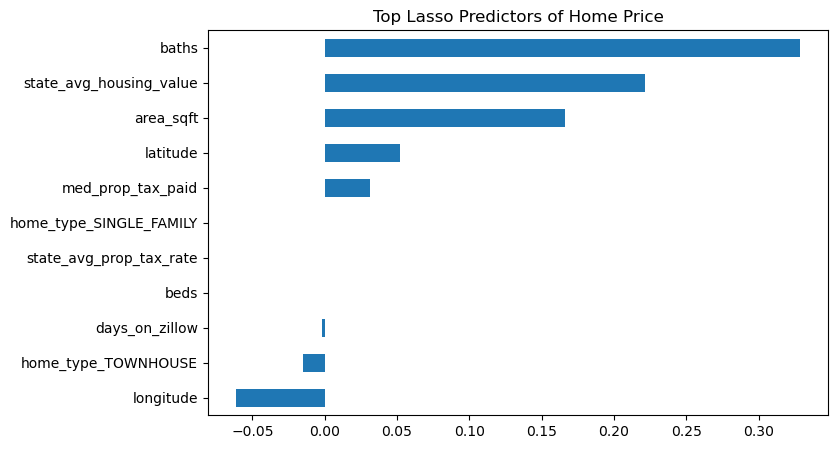

In [9]:
# Visualizations for Lasso coefficients 
top = lasso_sorted

plt.figure(figsize=(8,5))
top.sort_values().plot(kind="barh")
plt.title("Top Lasso Predictors of Home Price")
plt.show()

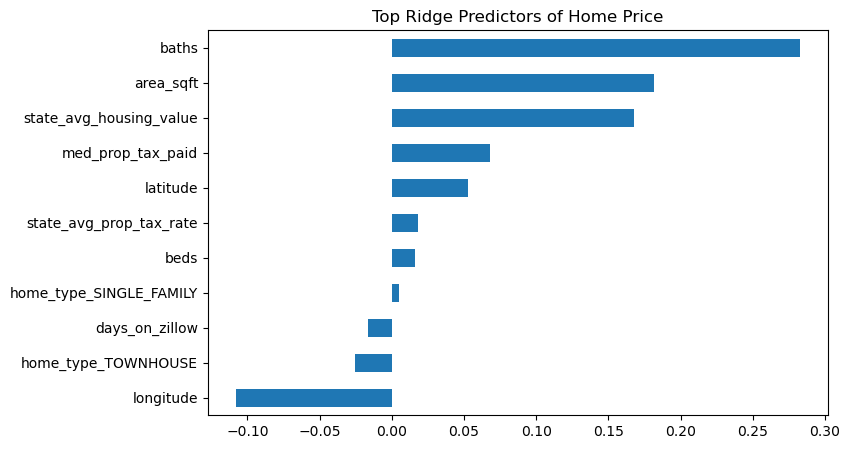

In [10]:
# Visualizations for Ridge (probably not super necessary but just good to compare to )
top_ridge = ridge_sorted

plt.figure(figsize=(8,5))
top_ridge.sort_values().plot(kind="barh")
plt.title("Top Ridge Predictors of Home Price")
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.utils import resample

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [12]:
df.columns

Index(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',
       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',
       'zestimate', 'detail_url', 'has_open_house', 'is_featured',
       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',
       'state_name', 'state_avg_housing_value', 'state_avg_prop_tax_rate',
       'med_prop_tax_paid', 'single_filer_rates', 'single_filer_brackets',
       'married_filing_jointly_rates', 'married_filing_jointly_brackets'],
      dtype='object')

## Decision Trees

Number of Features: 11


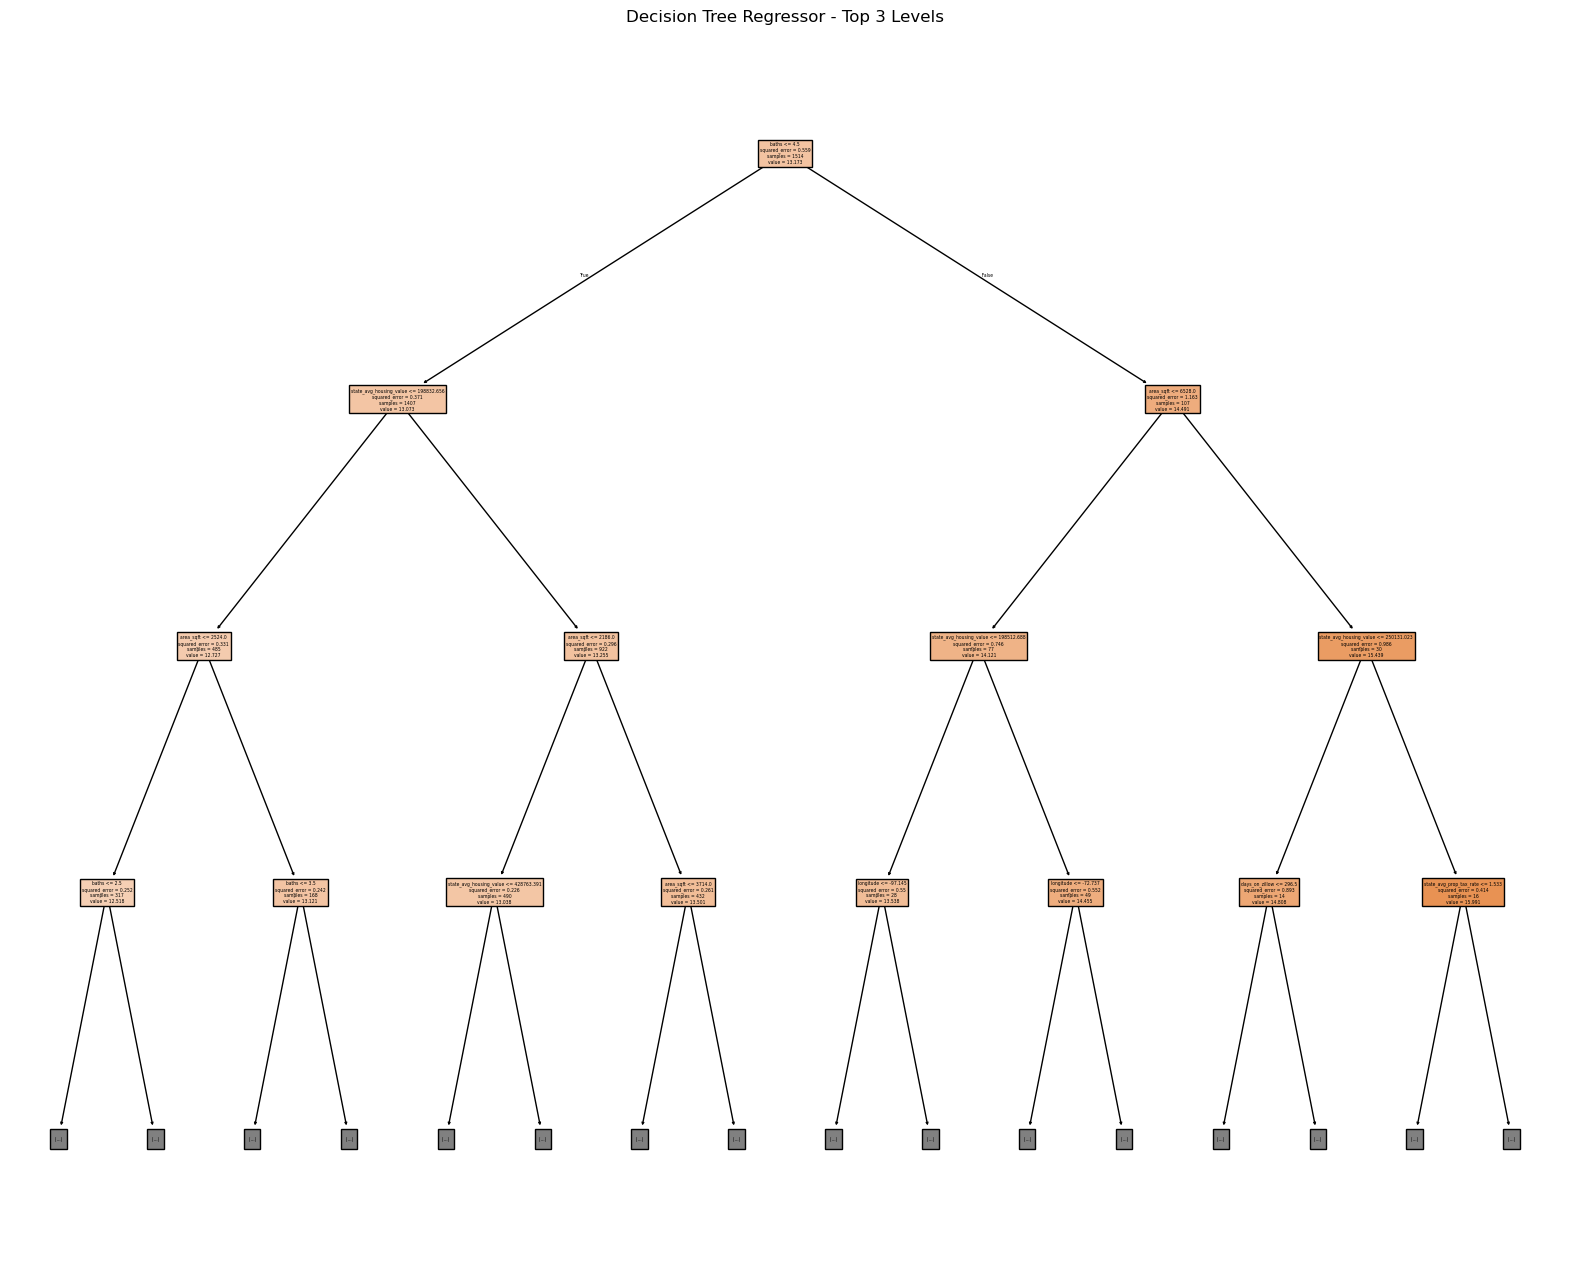

In [14]:
# copy predictors from X_train

random_state = 42
PREDICTORS = list(X_train.columns)

print(f'Number of Features: {len(PREDICTORS)}')

# Decision Tree Model

dt_single = DecisionTreeRegressor(random_state=random_state)
dt_single.fit(X_train[PREDICTORS], y_train)


fig = plt.figure(figsize=(20,16))
tree.plot_tree(dt_single, feature_names=PREDICTORS, filled=True, max_depth=3)
plt.title('Decision Tree Regressor - Top 3 Levels')
plt.show()

In [19]:
y_hat_train_dt = dt_single.predict(X_train[PREDICTORS])
y_hat_test_dt = dt_single.predict(X_test[PREDICTORS])

mse_train_dt = mean_squared_error(y_train, y_hat_train_dt)
mae_train_dt = mean_absolute_error(y_train, y_hat_train_dt)

mse_test_dt = mean_squared_error(y_test, y_hat_test_dt)
mae_test_dt = mean_absolute_error(y_test, y_hat_test_dt)

print(f"MSE (Train): {mse_train_dt}")
print(f"MAE (Train): {mae_train_dt}")

print(f"MSE (Test): {mse_test_dt}")
print(f"MAE (Test): {mae_test_dt}")

dollar_mae_train_dt = mean_absolute_error(np.exp(y_train), np.exp(y_hat_train_dt))
dollar_mae_test_dt = mean_absolute_error(np.exp(y_test), np.exp(y_hat_test_dt))

print(f"MAE in Dollars (Train): ${dollar_mae_train_dt:,.2f}")
print(f"MAE in Dollars (Test): ${dollar_mae_test_dt:,.2f}")

MSE (Train): 0.0
MAE (Train): 0.0
MSE (Test): 0.4056701216862818
MAE (Test): 0.44581846981857065
MAE in Dollars (Train): $0.00
MAE in Dollars (Test): $378,496.27


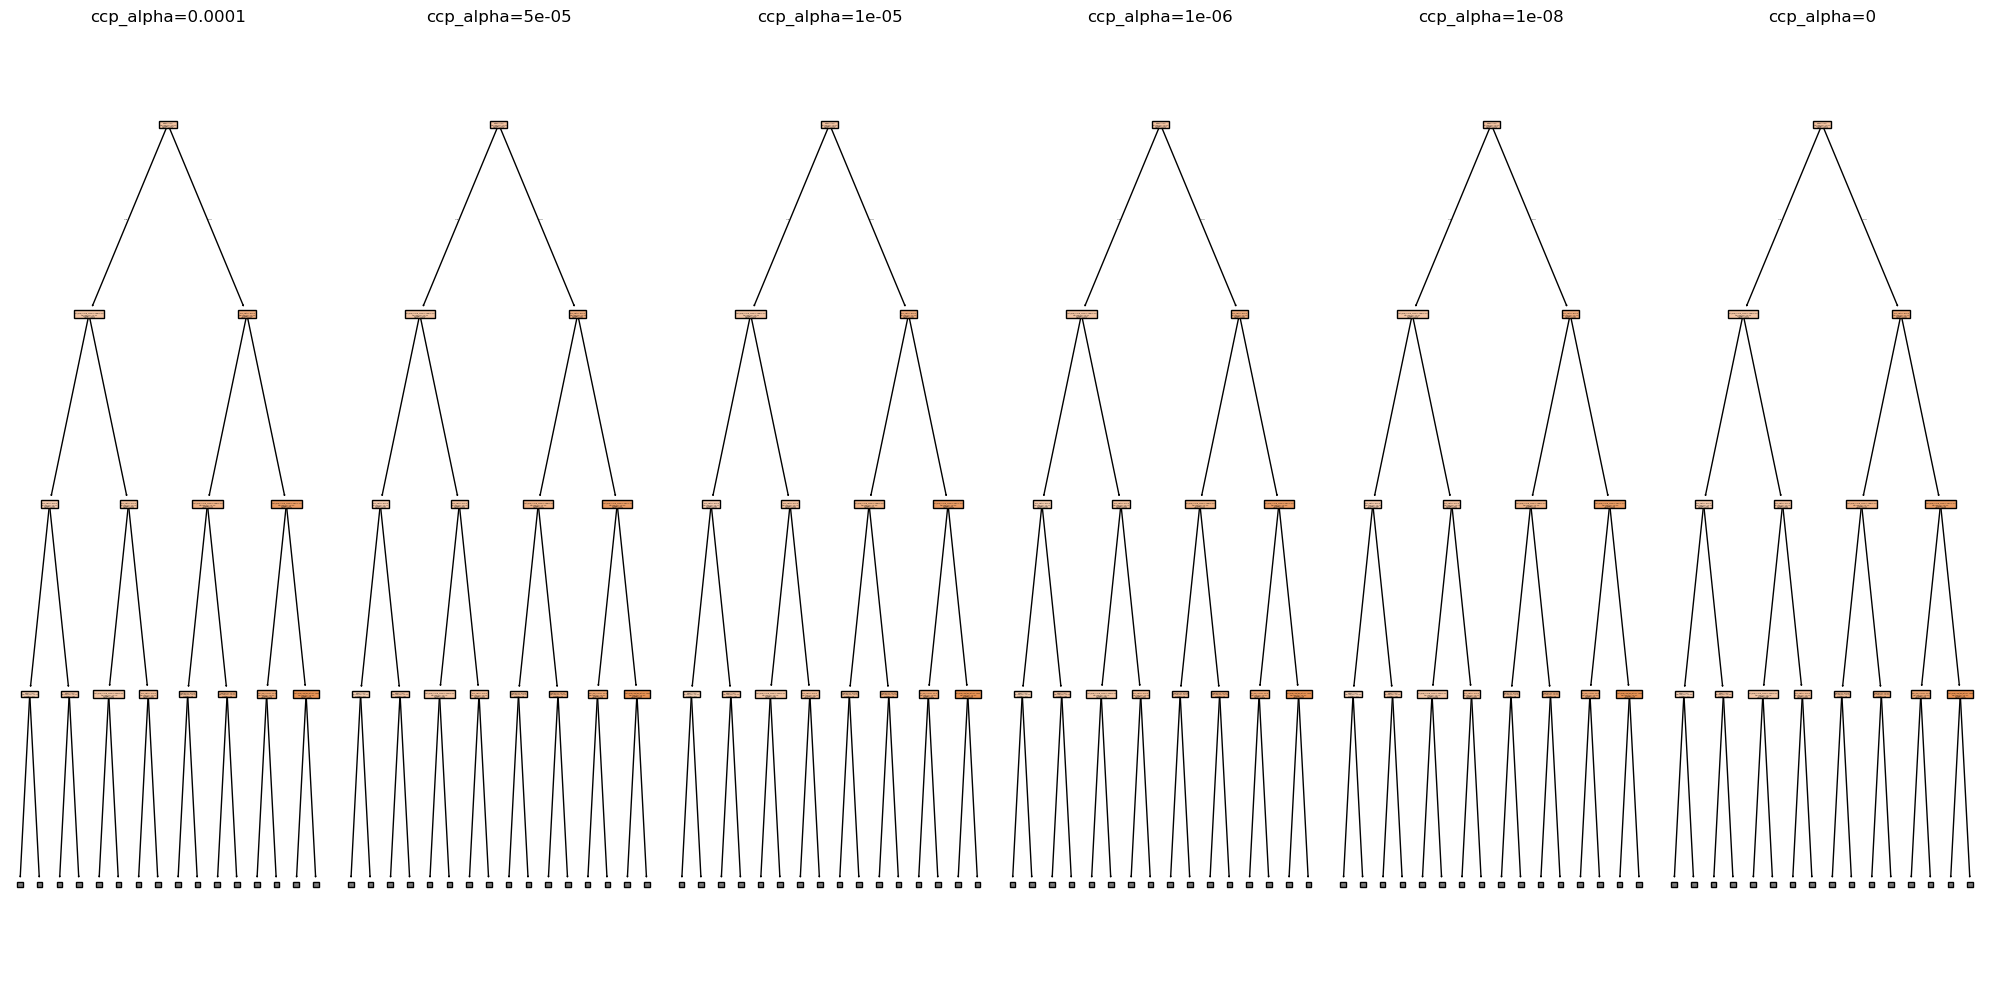

In [21]:
# replicated from lab 6

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20, 10))
alphas_ccp = [0.0001, 0.00005, 0.00001, 0.000001, 0.00000001, 0]
ctr = 1
for a in alphas_ccp:
  dt_plots = DecisionTreeRegressor(ccp_alpha=a, random_state=random_state)
  dt_plots.fit(X_train[PREDICTORS], y_train)
  plt.subplot(1, len(alphas_ccp), ctr)
  ctr+=1
  tree.plot_tree(dt_plots, feature_names=PREDICTORS, filled=True, max_depth=3)
  plt.title(f'ccp_alpha={a}')
  plt.tight_layout()

## Random Forest Models

In [24]:
# Replicated from HW 2

n_estimators = 100 # number of trees
max_features = (np.sqrt(X_train.shape[1]).astype(int)) # forces RF to look at a subset of features for each tree
ccp_alpha_rf = 0

print(f'Number of Trees: {n_estimators}')
print(f'Max Number of Features: {max_features}')

Number of Trees: 100
Max Number of Features: 3


In [25]:
# Random Forest Regressor Modeling

trees = []

for b in range(n_estimators):
    rs = random_state + b # ensures different random state for each tree
    X_train_sample, y_train_sample = resample(X_train, y_train, random_state=rs)

    dt = DecisionTreeRegressor(max_features=max_features, ccp_alpha=ccp_alpha_rf, random_state=rs)
    dt.fit(X_train_sample, y_train_sample)

    trees.append(dt)

# data integrity check, ensures X trees were created and added to the list
print(f'Number of trees created: {len(trees)}')

Number of trees created: 100


In [28]:
# double check this is correct
def predict(trees, X):
    rf_preds = np.array([tree.predict(X) for tree in trees])
    return np.mean(rf_preds, axis=0)

yhat_train_rf = predict(trees, X_train)
yhat_test_rf = predict(trees, X_test)

mse_train_rf = mean_squared_error(y_train, yhat_train_rf)
mae_train_rf = mean_absolute_error(y_train, yhat_train_rf)

mse_test_rf = mean_squared_error(y_test, yhat_test_rf)
mae_test_rf = mean_absolute_error(y_test, yhat_test_rf)

print(f"MSE (Train): {mse_train_rf}")
print(f"MAE (Train): {mae_train_rf}")

print(f"MSE (Test): {mse_test_rf}")
print(f"MAE (Test): {mae_test_rf}")


dollar_mae_train_rf = mean_absolute_error(np.exp(y_train), np.exp(yhat_train_rf))
dollar_mae_test_rf = mean_absolute_error(np.exp(y_test), np.exp(yhat_test_rf))

print(f"MAE in Dollars (Train): ${dollar_mae_train_rf:,.2f}")
print(f"MAE in Dollars (Test): ${dollar_mae_test_rf:,.2f}")


MSE (Train): 0.030130210696480406
MAE (Train): 0.11506769700012519
MSE (Test): 0.17860373148007205
MAE (Test): 0.30794308112851465
MAE in Dollars (Train): $139,124.62
MAE in Dollars (Test): $263,812.25


In [38]:
mse_train_seq_rf = np.zeros(n_estimators)
mse_test_seq_rf = np.zeros(n_estimators)

# loop over the range 1 to n_estimators
for b in range(n_estimators):
  yhat_train_it = predict(trees[:b+1], X_train)
  yhat_test_it = predict(trees[:b+1], X_test)

  mse_train_seq_rf[b] = mean_squared_error(y_train, yhat_train_it)
  mse_test_seq_rf[b] = mean_squared_error(y_test, yhat_test_it)


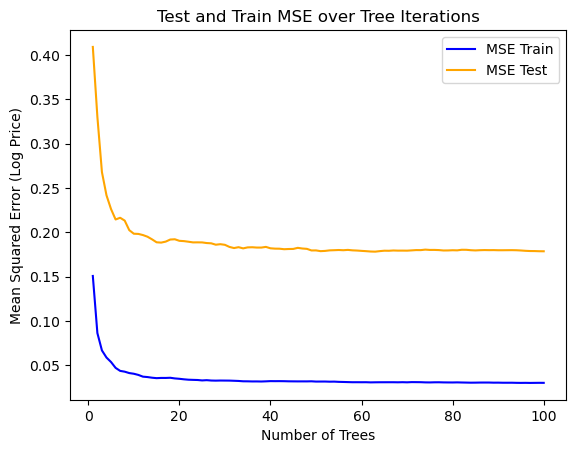

In [39]:
plt.plot(range(1, n_estimators + 1), mse_train_seq_rf, label='MSE Train', c='blue')
plt.plot(range(1, n_estimators + 1), mse_test_seq_rf, label='MSE Test', c='orange')
plt.xlabel('Number of Trees')
plt.ylabel('Mean Squared Error (Log Price)')
plt.legend()
plt.title("Test and Train MSE over Tree Iterations")
plt.show()